In [1]:
import math

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
%matplotlib inline

In [5]:
def f(x):
    return 3*x**2

In [6]:
f(3.0)

27.0

In [7]:
f(3)

27

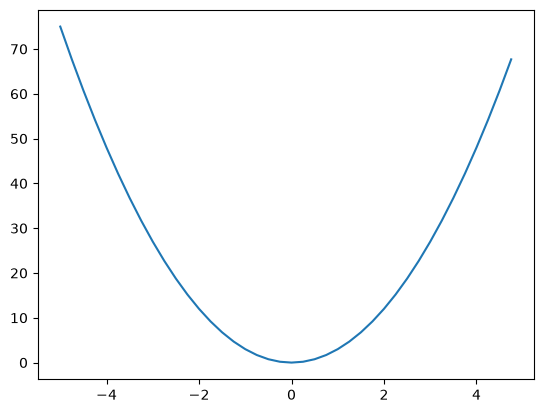

In [8]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [9]:
h=0.0001
def ff(x):
    return (f(x+h)-f(x-h))/(2*h)

In [10]:
zs=ff(xs) 

In [11]:
print(zs)

[-30.  -28.5 -27.  -25.5 -24.  -22.5 -21.  -19.5 -18.  -16.5 -15.  -13.5
 -12.  -10.5  -9.   -7.5  -6.   -4.5  -3.   -1.5   0.    1.5   3.    4.5
   6.    7.5   9.   10.5  12.   13.5  15.   16.5  18.   19.5  21.   22.5
  24.   25.5  27.   28.5]


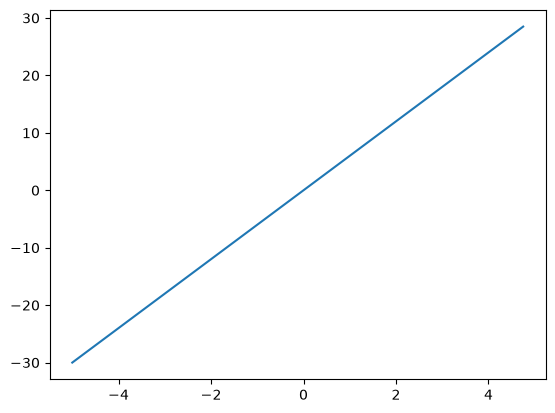

In [12]:
plt.plot(xs,zs)

In [13]:
print(ff(0))

0.0


In [14]:
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [15]:
a=2.0
b=-3.0
c=10.0
h=0.0001
d1=a*b+c
c+=h
d2=a*b+c
dd=(d2-d1)/h
print('d1 =',d1)
print('d2 =',d2)
print('slope =',dd)

d1 = 4.0
d2 = 4.0001
slope = 0.9999999999976694


In [16]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data  #数值
        self.grad = 0.0  #梯度
        self._prev=set(_children)  #树结构引用
        self._op=_op  #符号
        self.label=label  #标签
        self._backward = lambda: None
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        out = Value(self.data+other.data,(self,other),'+')

        def _backward():  
            #这里所运用的语法是python的闭包
            #python将函数视作对象
            #所以可以直接传递函数到下一个对象
            self.grad=1.0*out.grad
            other.grad=1.0*out.grad
        out._backward=_backward
        return out
        
    def __mul__(self,other):
        out = Value(self.data*other.data,(self,other),'*')

        def _backward():
            self.grad=other.data*out.grad
            other.grad=self.data*out.grad
        out._backward=_backward
        return out
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad=(1-t**2)*out.grad
        out._backward=_backward
        
        return out

    def backward(self):
        

In [17]:
a=Value(2.0,label='a')
b=Value(-3.0,label='b')
c=Value(10.0,label='c') 
e=a*b; e.label='e'
d=e+c;d.label='d'
f=Value(-2.0,label='f')
L=d*f
L.label='L'
L

Value(data=-8.0)

In [18]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


画图函数，不需要理解，只需要知道下面的图是这个函数画的

In [19]:
f.grad=4.0
d.grad=-2.0
e.grad=-2.0
c.grad=-2.0
a.grad=6.0
b.grad=-4.0

In [20]:
L.grad = 1.0

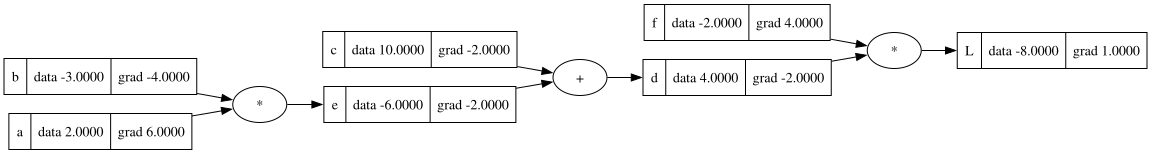

In [21]:
draw_dot(L)

In [22]:
h=0.01
a.data+=h*a.grad
b.data+=h*b.grad
c.data+=h*c.grad
f.data+=h*f.grad

e=a*b
d=e+c
L=d*f

print(L.data)

-7.286496


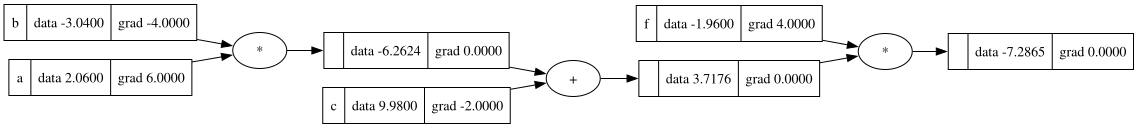

In [23]:
draw_dot(L)

In [24]:
def lol():
    h=0.0001
    
    a=Value(2.0,label='a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c') 
    e=a*b; e.label='e'
    d=e+c;d.label='d'
    f=Value(-2.0,label='f')
    L=d*f
    L.label='L'
    L1=L.data

    a=Value(2.0+h,label='a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c') 
    e=a*b; e.label='e'
    d=e+c;d.label='d'
    f=Value(-2.0,label='f')
    L=d*f
    L.label='L'
    L2=L.data

    dd=(L2-L1)/h
    return(dd)

这一个单元格是用来隔离变量的，用来展示导数的求法

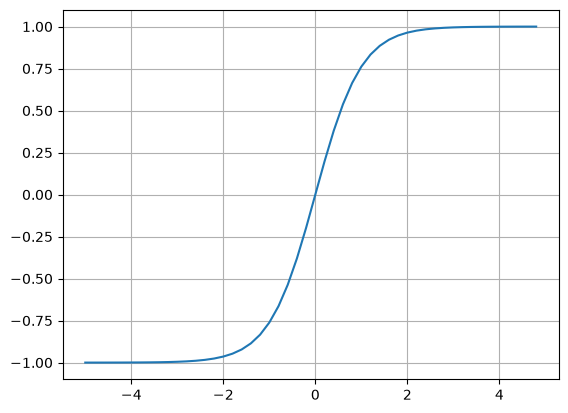

In [25]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)))
plt.grid()

这里这个函数被称作压缩函数。因为即将进入神经元阶段：
神经元的模拟是这样的：
每一个神经元会接收多个神经元传递过来的电信号
电信号会累加，当累加到一定值之后神经元就会放电
现在我们要计算的就是这个累加值
然后关于这个累加值我们需要一个判定标准
于是乎我们就用压缩函数
将算出来的值平滑的压缩到-1～1
这样的话就可以去更灵活的判断这个值的价值与大小
接下来是神经元的具体实现过程

In [26]:
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
b=Value(6.8813735870195432,label='b')
x1w1=x1*w1
x1w1.label='x1w1'
x2w2=x2*w2
x2w2.label='x2w2'
x1w1x2w2=x1w1+x2w2
x1w1x2w2.label='x1w1x2w2'
n=x1w1x2w2+b
n.label='n'

这里的x1x2是input，w1w2是weight，b被称作bias——偏置，这个b不是太重要主要是要让最终结果尽量偏向活跃值，否则当x1x2都为0的时候整个式子就是0了。
最后的式子就是n=x1*w1+x2*w2+b

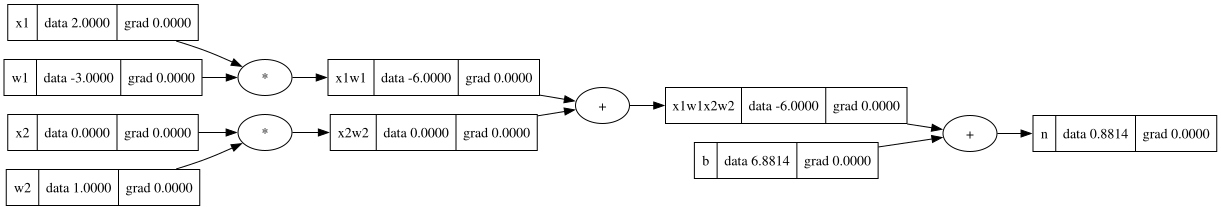

In [27]:
draw_dot(n)

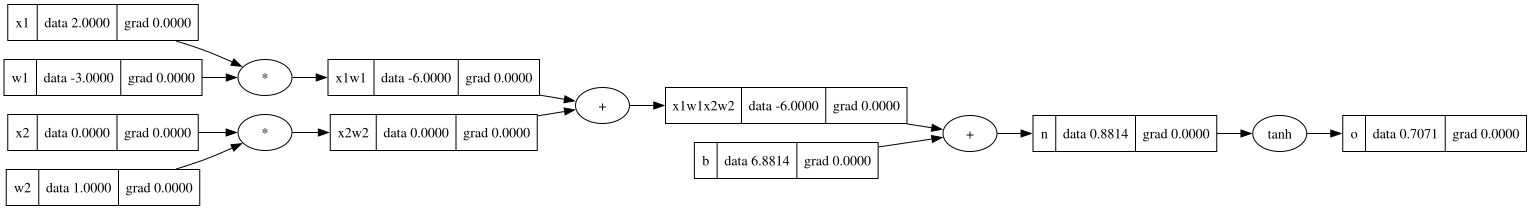

In [28]:
o=n.tanh();o.label='o'
draw_dot(o)

In [29]:
o.grad=1.0

In [30]:
n.grad=1-o.data**2
print(n.grad)

0.4999999999999999


In [31]:
b.grad=n.grad
x1w1x2w2.grad=n.grad
x1w1.grad=n.grad
x2w2.grad=n.grad
x1.grad=x1w1.grad*w1.data
w1.grad=x1w1.grad*x1.data
x2.grad=x2w2.grad*w2.data
w2.grad=x2w2.grad*x2.data

这里是手动反向传播

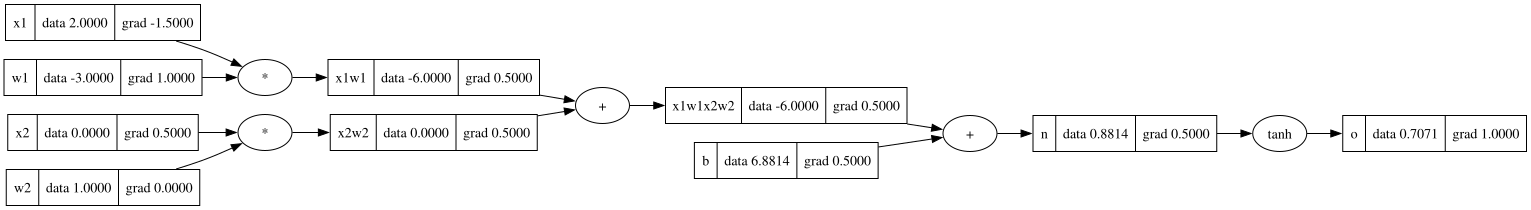

In [32]:
draw_dot(o)

In [33]:
#重置梯度
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
b=Value(6.8813735870195432,label='b')
x1w1=x1*w1
x1w1.label='x1w1'
x2w2=x2*w2
x2w2.label='x2w2'
x1w1x2w2=x1w1+x2w2
x1w1x2w2.label='x1w1x2w2'
n=x1w1x2w2+b
n.label='n'
o=n.tanh()
o.label='o'
o.grad=1

现在来尝试自动反向传播计算

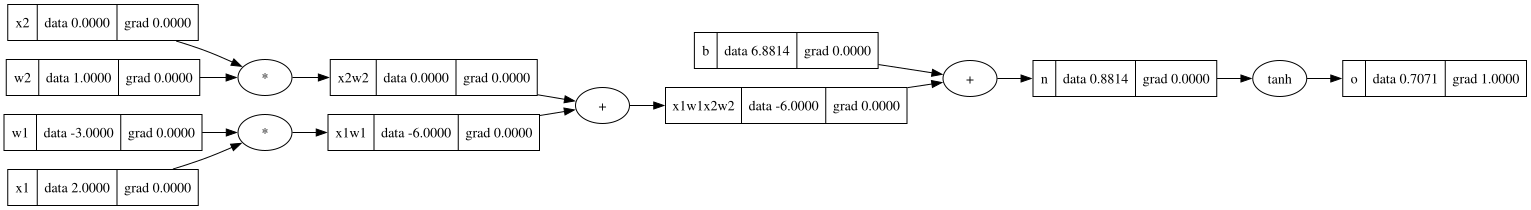

In [34]:
draw_dot(o)

In [35]:
# o.grad=1.0
# o._backward()

In [36]:
# draw_dot(o)

In [37]:
#如你所见，现在我们已经完成了利用函数的反向传播

In [38]:
#现在我们来尝试一下自己实现一个o._backward就能实现所有的_backward

In [39]:
#ok啊也是自己实现了一个自动的反向传播函数

In [40]:
#好像不太对，神经网络好像是可以出现环的
#修改一下逻辑，用拓扑结构来遍历所有的节点从而实现grad的更新
#上面的自动反向传播就先删掉了

In [41]:
topo=[]
visited=set()

#拓扑函数，将整个拓扑结构存储到列表topo里
#采用递归的方式对根节点进行调用
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

#调用根节点
build_topo(o)
topo   

[Value(data=6.881373587019543),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [42]:
#重置梯度
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
b=Value(6.8813735870195432,label='b')
x1w1=x1*w1
x1w1.label='x1w1'
x2w2=x2*w2
x2w2.label='x2w2'
x1w1x2w2=x1w1+x2w2
x1w1x2w2.label='x1w1x2w2'
n=x1w1x2w2+b
n.label='n'
o=n.tanh()
o.label='o'
o.grad=1.0

In [43]:
build_topo(o)

for node in reversed(topo):
    node._backward()

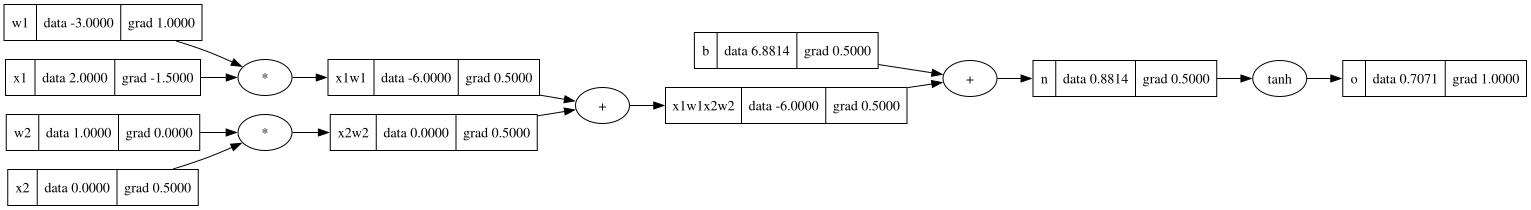

In [44]:
draw_dot(o)

In [45]:
#拓扑反向成功，接下来要尝试将拓扑结构函数直接融入Value类